# Universidad Libre - Seccional Cali<br>Facultad de Ingeniería - Diplomado en Ciencia de Datos<br>(ↄ) Diego Fernando Marin, 2024

# 04_modelo
Plantilla para el desarrollo del proyecto del diplomado de Ciencia de Datos, aplicando buenas prácticas.

---

Este cuaderno representa la culminación del proceso, donde aplicamos técnicas de machine learning para crear modelos predictivos o descriptivos basados en los datos preparados.

**Propósito:** Desarrollar, entrenar y validar modelos de machine learning que respondan a los objetivos del proyecto.

**Tareas habituales:**
- Selección de características (feature selection)
- Ingeniería de características (feature engineering)
- División de datos en conjuntos de entrenamiento y prueba
- Selección y entrenamiento de modelos
- Optimización de hiperparámetros
- Validación cruzada
- Evaluación de métricas de rendimiento
- Documentación del proceso de modelado
- Guardado y versionado de modelos
- Análisis de importancia de características

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

CLEAN_PATH = "/content/drive/MyDrive/proyecto_oro/data/clean/"
df = pd.read_csv(CLEAN_PATH + "oro_cop_limpio.csv", index_col='DATE', parse_dates=True)

# Retornos
df['retorno_oro_cop']  = df['oro_cop'].pct_change()
df['retorno_usd_cop']  = df['usd_cop_Close'].pct_change()
df['retorno_dxy']      = df['dxy_Close'].pct_change()
df['retorno_vix']      = df['vix_Close'].pct_change()
df['retorno_wti']      = df['wti_crudo_Close'].pct_change()
df['retorno_bono_10y'] = df['bono_10y_Close'].pct_change()

# Lags seleccionados de usd_cop (validados en EDA)
for lag in [5, 8, 10, 16]:
    df[f'usd_cop_lag_{lag}'] = df['retorno_usd_cop'].shift(lag)

# Variables macro con 1 día de rezago (sin fuga de información)
df['retorno_dxy_lag1']      = df['retorno_dxy'].shift(1)
df['retorno_vix_lag1']      = df['retorno_vix'].shift(1)
df['retorno_wti_lag1']      = df['retorno_wti'].shift(1)
df['retorno_bono_10y_lag1'] = df['retorno_bono_10y'].shift(1)

# Dummies de día de semana
dummies_dia = pd.get_dummies(df.index.dayofweek, prefix='dia', drop_first=True)
dummies_dia.index = df.index
df = pd.concat([df, dummies_dia], axis=1)

print(f"Filas: {len(df)} | Columnas: {len(df.columns)}")

Mounted at /content/drive
Filas: 1377 | Columnas: 25


In [2]:
FEATURES = [
    'usd_cop_lag_5', 'usd_cop_lag_8', 'usd_cop_lag_10', 'usd_cop_lag_16',
    'dia_1', 'dia_2', 'dia_3', 'dia_4',
    'retorno_dxy_lag1', 'retorno_vix_lag1', 'retorno_wti_lag1', 'retorno_bono_10y_lag1',
]
TARGET = 'retorno_oro_cop'

df_modelo = df.dropna(subset=FEATURES + [TARGET])
X = df_modelo[FEATURES]
y = df_modelo[TARGET]

print(f"Filas para entrenar: {len(df_modelo)}")

Filas para entrenar: 1360


In [3]:
tscv = TimeSeriesSplit(n_splits=6)
resultados = []

for i, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    modelo = LinearRegression()
    modelo.fit(X_tr, y_tr)
    pred = modelo.predict(X_te)

    rmse_modelo = np.sqrt(mean_squared_error(y_te, pred))
    rmse_ref = np.sqrt(mean_squared_error(y_te, np.zeros(len(y_te))))
    mejora_pct = (rmse_ref - rmse_modelo) / rmse_ref * 100

    resultados.append({
        'ventana': i, 'rmse_modelo': rmse_modelo,
        'rmse_referencia': rmse_ref, 'mejora_%': mejora_pct,
        'gano': rmse_modelo < rmse_ref
    })

df_resultados = pd.DataFrame(resultados)
print(df_resultados)
print(f"\nVentanas ganadas: {df_resultados['gano'].sum()} de {len(df_resultados)}")
print(f"Mejora promedio: {df_resultados['mejora_%'].mean():.2f}%")

   ventana  rmse_modelo  rmse_referencia  mejora_%  gano
0        1     0.013120         0.013180  0.454419  True
1        2     0.015167         0.016018  5.309125  True
2        3     0.011752         0.012471  5.762149  True
3        4     0.012157         0.013196  7.870126  True
4        5     0.013881         0.014704  5.599725  True
5        6     0.021304         0.021609  1.415121  True

Ventanas ganadas: 6 de 6
Mejora promedio: 4.40%


In [4]:
!pip install lightgbm xgboost --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                    BayesianRidge, HuberRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                                AdaBoostRegressor, ExtraTreesRegressor)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [5]:
modelos = {
    "Linear Regression":    LinearRegression(),
    "Ridge":                Ridge(alpha=1.0),
    "Lasso":                Lasso(alpha=0.001),
    "ElasticNet":           ElasticNet(alpha=0.001),
    "Bayesian Ridge":       BayesianRidge(),
    "Huber Regressor":      HuberRegressor(),
    "Decision Tree":        DecisionTreeRegressor(max_depth=4, random_state=42),
    "Random Forest":        RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42),
    "Extra Trees":          ExtraTreesRegressor(n_estimators=200, max_depth=4, random_state=42),
    "Gradient Boosting":    GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    "AdaBoost":             AdaBoostRegressor(n_estimators=100, random_state=42),
    "LightGBM":             LGBMRegressor(n_estimators=100, max_depth=4, verbose=-1, random_state=42),
    "XGBoost":              XGBRegressor(n_estimators=100, max_depth=3, random_state=42, verbosity=0),
    "SVR (RBF)":            SVR(kernel='rbf', C=1.0),
    "K-Nearest Neighbors":  KNeighborsRegressor(n_neighbors=10),
}

print(f"Total de modelos a probar: {len(modelos)}")

Total de modelos a probar: 15


In [6]:
tscv = TimeSeriesSplit(n_splits=6)
resultados_todos = []

for nombre, modelo in modelos.items():
    rmses_modelo = []
    rmses_ref = []

    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        modelo.fit(X_tr, y_tr)
        pred = modelo.predict(X_te)

        rmses_modelo.append(np.sqrt(mean_squared_error(y_te, pred)))
        rmses_ref.append(np.sqrt(mean_squared_error(y_te, np.zeros(len(y_te)))))

    rmse_prom = np.mean(rmses_modelo)
    rmse_ref_prom = np.mean(rmses_ref)
    mejora_pct = (rmse_ref_prom - rmse_prom) / rmse_ref_prom * 100
    ventanas_ganadas = sum(m < r for m, r in zip(rmses_modelo, rmses_ref))

    resultados_todos.append({
        "modelo": nombre,
        "rmse_promedio": rmse_prom,
        "mejora_%": mejora_pct,
        "ventanas_ganadas": ventanas_ganadas,
    })
    print(f"✓ {nombre}: RMSE={rmse_prom:.5f} | mejora={mejora_pct:.2f}% | ganó {ventanas_ganadas}/6")

df_ranking = pd.DataFrame(resultados_todos).sort_values("mejora_%", ascending=False).reset_index(drop=True)

✓ Linear Regression: RMSE=0.01456 | mejora=4.16% | ganó 6/6
✓ Ridge: RMSE=0.01489 | mejora=2.00% | ganó 5/6
✓ Lasso: RMSE=0.01519 | mejora=0.07% | ganó 4/6
✓ ElasticNet: RMSE=0.01517 | mejora=0.16% | ganó 5/6
✓ Bayesian Ridge: RMSE=0.01484 | mejora=2.37% | ganó 6/6


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_

✓ Huber Regressor: RMSE=0.01467 | mejora=3.47% | ganó 5/6
✓ Decision Tree: RMSE=0.01569 | mejora=-3.23% | ganó 1/6
✓ Random Forest: RMSE=0.01495 | mejora=1.65% | ganó 5/6
✓ Extra Trees: RMSE=0.01485 | mejora=2.30% | ganó 5/6
✓ Gradient Boosting: RMSE=0.01538 | mejora=-1.21% | ganó 5/6
✓ AdaBoost: RMSE=0.01499 | mejora=1.34% | ganó 4/6
✓ LightGBM: RMSE=0.01512 | mejora=0.47% | ganó 4/6
✓ XGBoost: RMSE=0.01589 | mejora=-4.59% | ganó 1/6
✓ SVR (RBF): RMSE=0.01561 | mejora=-2.75% | ganó 2/6
✓ K-Nearest Neighbors: RMSE=0.01513 | mejora=0.43% | ganó 5/6


In [7]:
print(df_ranking.to_string())

                 modelo  rmse_promedio  mejora_%  ventanas_ganadas
0     Linear Regression       0.014564  4.163935                 6
1       Huber Regressor       0.014669  3.468624                 5
2        Bayesian Ridge       0.014836  2.372132                 6
3           Extra Trees       0.014847  2.301467                 5
4                 Ridge       0.014893  1.997537                 5
5         Random Forest       0.014946  1.648443                 5
6              AdaBoost       0.014992  1.340920                 4
7              LightGBM       0.015124  0.473861                 4
8   K-Nearest Neighbors       0.015131  0.427588                 5
9            ElasticNet       0.015172  0.161685                 5
10                Lasso       0.015186  0.068660                 4
11    Gradient Boosting       0.015381 -1.214669                 5
12            SVR (RBF)       0.015613 -2.745050                 2
13        Decision Tree       0.015687 -3.231746              

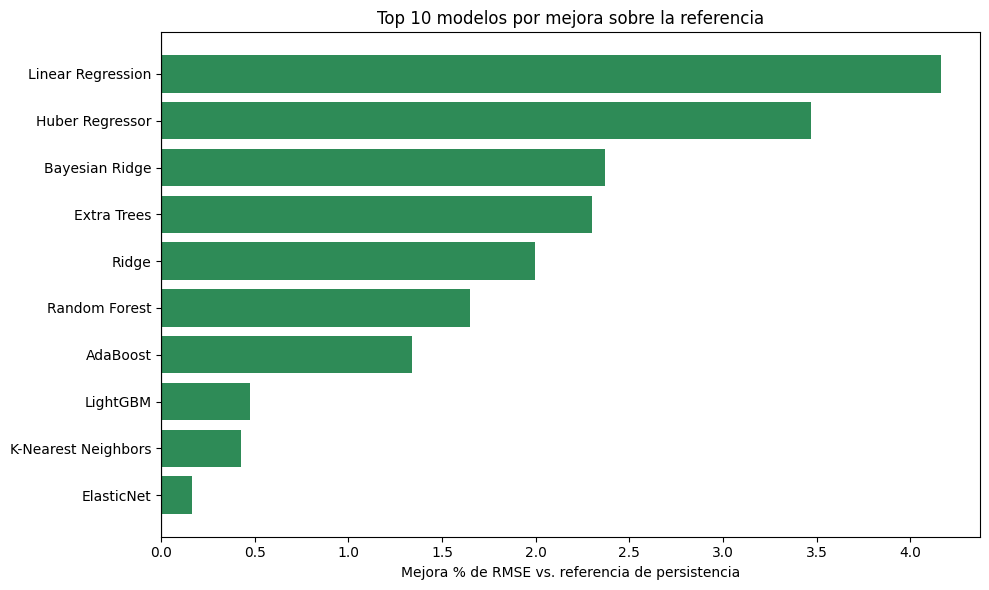

In [8]:
top10 = df_ranking.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['seagreen' if v > 0 else 'indianred' for v in top10['mejora_%']]
ax.barh(top10['modelo'][::-1], top10['mejora_%'][::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mejora % de RMSE vs. referencia de persistencia')
ax.set_title('Top 10 modelos por mejora sobre la referencia')
plt.tight_layout()
plt.show()

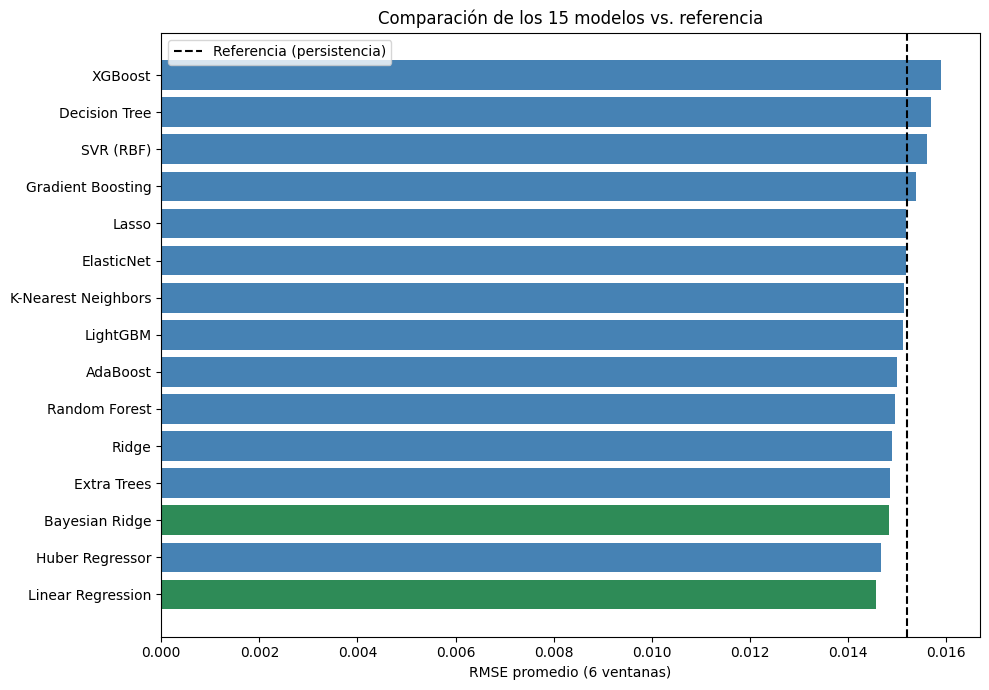

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))
df_plot = df_ranking.sort_values("rmse_promedio")
colores2 = ['seagreen' if g == 6 else 'steelblue' for g in df_plot['ventanas_ganadas']]
ax.barh(df_plot['modelo'], df_plot['rmse_promedio'], color=colores2)
ax.axvline(rmse_ref_prom, color='black', linestyle='--', label='Referencia (persistencia)')
ax.set_xlabel('RMSE promedio (6 ventanas)')
ax.set_title('Comparación de los 15 modelos vs. referencia')
ax.legend()
plt.tight_layout()
plt.show()

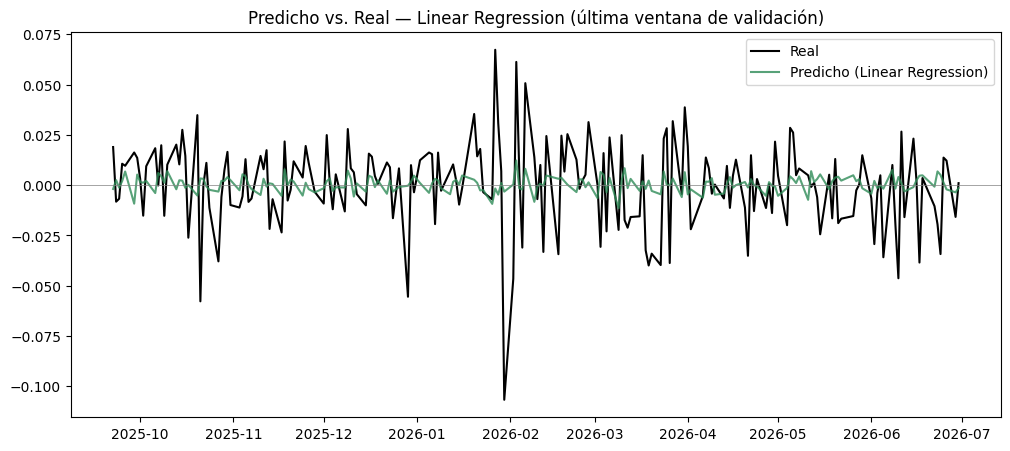

In [10]:
mejor_nombre = df_ranking.iloc[0]['modelo']
mejor_modelo = modelos[mejor_nombre]

train_idx, test_idx = list(tscv.split(X))[-1]
X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

mejor_modelo.fit(X_tr, y_tr)
pred_final = mejor_modelo.predict(X_te)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te.index, y_te.values, label='Real', color='black')
ax.plot(y_te.index, pred_final, label=f'Predicho ({mejor_nombre})', color='seagreen', alpha=0.8)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_title(f'Predicho vs. Real — {mejor_nombre} (última ventana de validación)')
ax.legend()
plt.show()

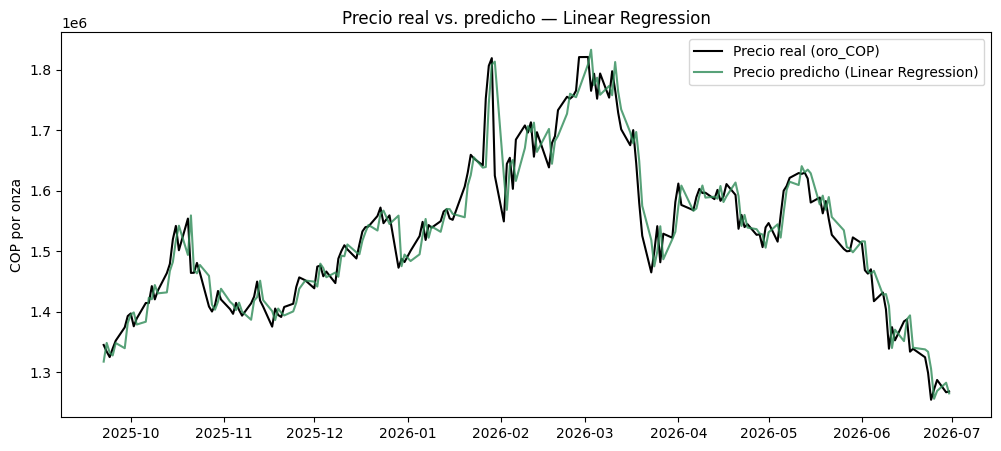

In [11]:
# Necesitamos el precio real de oro_cop en la ventana de test, alineado
precio_real_test = df_modelo.loc[y_te.index, 'oro_cop']

# Reconstrucción: precio_hoy_real * (1 + retorno_predicho) = precio_predicho_mañana
# Para comparar en la misma escala de tiempo, usamos el precio del día anterior
precio_anterior = df_modelo['oro_cop'].shift(1).loc[y_te.index]
precio_predicho = precio_anterior * (1 + pred_final)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te.index, precio_real_test, label='Precio real (oro_COP)', color='black')
ax.plot(y_te.index, precio_predicho, label=f'Precio predicho ({mejor_nombre})', color='seagreen', alpha=0.8)
ax.set_title(f'Precio real vs. predicho — {mejor_nombre}')
ax.set_ylabel('COP por onza')
ax.legend()
plt.show()

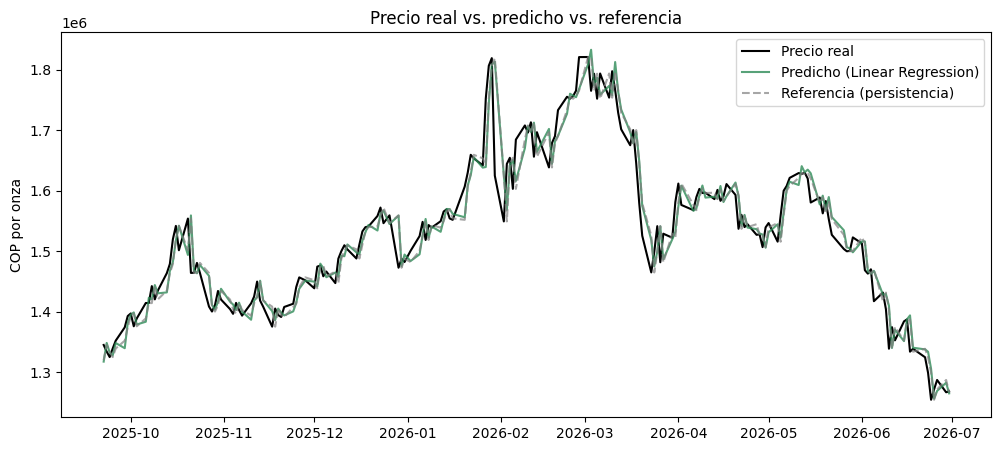

In [12]:
precio_predicho_referencia = precio_anterior  # persistencia = precio de ayer

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(y_te.index, precio_real_test, label='Precio real', color='black')
ax.plot(y_te.index, precio_predicho, label=f'Predicho ({mejor_nombre})', color='seagreen', alpha=0.8)
ax.plot(y_te.index, precio_predicho_referencia, label='Referencia (persistencia)', color='gray', linestyle='--', alpha=0.7)
ax.set_title('Precio real vs. predicho vs. referencia')
ax.set_ylabel('COP por onza')
ax.legend()
plt.show()

In [13]:
tabla_prediccion = pd.DataFrame({
    'precio_ayer': precio_anterior,
    'retorno_predicho': pred_final,
    'precio_estimado': precio_predicho,
    'precio_real_hoy': precio_real_test,
})

tabla_prediccion['error_COP'] = tabla_prediccion['precio_real_hoy'] - tabla_prediccion['precio_estimado']
tabla_prediccion['error_%'] = (tabla_prediccion['error_COP'] / tabla_prediccion['precio_real_hoy']) * 100

print(tabla_prediccion.head(15).round(2))

            precio_ayer  retorno_predicho  precio_estimado  precio_real_hoy  \
DATE                                                                          
2025-09-22   1320258.12             -0.00       1317769.16       1345315.36   
2025-09-23   1345315.36              0.00       1348709.77       1334286.70   
2025-09-24   1334286.70             -0.00       1332639.56       1325301.06   
2025-09-25   1325301.06              0.00       1327976.36       1339436.49   
2025-09-26   1339436.49              0.01       1348541.42       1352372.65   
2025-09-29   1352372.65             -0.01       1339937.91       1374368.43   
2025-09-30   1374368.43              0.01       1381632.66       1393086.93   
2025-10-01   1393086.93              0.00       1395278.24       1397328.74   
2025-10-02   1397328.74              0.00       1399058.05       1376145.30   
2025-10-03   1376145.30              0.00       1379086.73       1389120.27   
2025-10-06   1389120.27             -0.00       1383

In [14]:
print("Resumen del error de predicción (en COP por onza):")
print(tabla_prediccion['error_COP'].abs().describe())

print(f"\nError absoluto promedio: {tabla_prediccion['error_COP'].abs().mean():,.0f} COP por onza")
print(f"Error porcentual promedio: {tabla_prediccion['error_%'].abs().mean():.3f}%")

Resumen del error de predicción (en COP por onza):
count       194.000000
mean      24927.442295
std       23028.344610
min          33.603454
25%       10657.919188
50%       18239.019639
75%       34161.178957
max      188367.322181
Name: error_COP, dtype: float64

Error absoluto promedio: 24,927 COP por onza
Error porcentual promedio: 1.619%


In [15]:
tabla_prediccion['precio_estimado_referencia'] = tabla_prediccion['precio_ayer']  # persistencia
tabla_prediccion['error_referencia_COP'] = tabla_prediccion['precio_real_hoy'] - tabla_prediccion['precio_estimado_referencia']

print("Comparación de error absoluto promedio:")
print(f"Tu modelo:    {tabla_prediccion['error_COP'].abs().mean():,.0f} COP ({tabla_prediccion['error_%'].abs().mean():.3f}%)")
print(f"Referencia:   {tabla_prediccion['error_referencia_COP'].abs().mean():,.0f} COP ({(tabla_prediccion['error_referencia_COP'].abs()/tabla_prediccion['precio_real_hoy']*100).mean():.3f}%)")

Comparación de error absoluto promedio:
Tu modelo:    24,927 COP (1.619%)
Referencia:   25,347 COP (1.646%)
